In [93]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

In [94]:
path = "data/StudentPerformanceFactors.csv"
df = pd.read_csv(path, sep=',', encoding='ISO-8859-1')

engine = create_engine("sqlite:///data/students.sqlite")
df.to_sql("students", engine, index=False, if_exists="replace")

6607

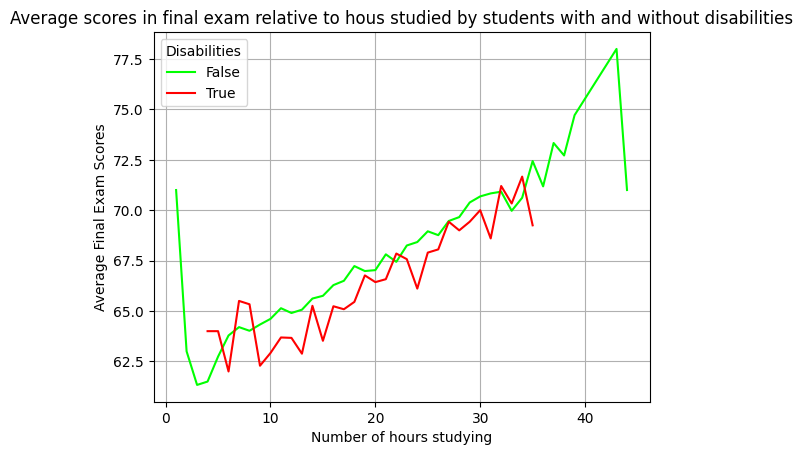

In [96]:
no_disabilities = pd.read_sql("""SELECT AVG(Exam_Score) AS mean, Hours_Studied FROM students
                       WHERE Learning_Disabilities = 'No'
                       GROUP BY Hours_Studied
                       ORDER BY Hours_studied""", engine)

disabilities = pd.read_sql("""SELECT AVG(Exam_Score) AS mean, Hours_Studied FROM students
                       WHERE Learning_Disabilities = 'Yes'
                       GROUP BY Hours_Studied
                       ORDER BY Hours_studied""", engine)

plt.plot(no_disabilities['Hours_Studied'], no_disabilities['mean'], color="lime")
plt.plot(disabilities['Hours_Studied'], disabilities['mean'], color="red")
plt.title("Average scores in final exam relative to hous studied by students with and without disabilities")
plt.legend(['False', 'True'], title="Disabilities")
plt.grid(True)
plt.xlabel("Number of hours studying")
plt.ylabel("Average Final Exam Scores")
plt.show()


<Axes: title={'center': 'Students access to resources distribuition'}>

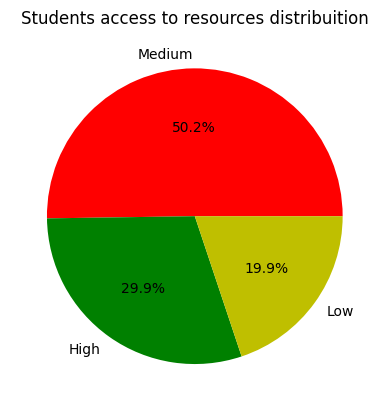

In [97]:
resources = df['Access_to_Resources'].value_counts()
resources.plot(kind='pie', autopct='%1.1f%%', ylabel='', title="Students access to resources distribuition",
               colors=['r', 'g', 'y'])

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [99]:
teste = pd.read_sql("""SELECT * FROM students WHERE Teacher_Quality IS NULL""", engine)
teste.head(2000)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,17,97,Medium,Medium,No,8,89,Medium,Yes,1,Low,None,Public,Neutral,4,No,High School,Far,Male,69
1,10,80,High,Medium,Yes,6,93,High,Yes,4,Medium,None,Public,Negative,3,No,College,Moderate,Female,67
2,14,86,Medium,Low,Yes,8,90,Medium,No,3,Medium,None,Public,Negative,3,Yes,Postgraduate,Near,Male,65
3,20,71,High,Medium,No,8,77,Medium,Yes,0,High,None,Private,Neutral,4,No,High School,Moderate,Male,66
4,22,82,High,Medium,Yes,7,71,Low,Yes,1,High,None,Private,Positive,3,No,High School,Near,Female,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,22,63,Low,Low,Yes,7,94,Medium,Yes,0,Medium,None,Public,Negative,3,Yes,High School,Far,Male,61
74,29,75,Low,Medium,Yes,7,96,Low,Yes,2,Low,None,Public,Positive,3,No,High School,Moderate,Male,68
75,12,89,Medium,High,Yes,8,78,Low,Yes,4,Low,None,Public,Neutral,5,No,Postgraduate,Near,Female,69
76,9,84,Medium,Medium,No,6,74,Medium,Yes,5,High,None,Public,Neutral,2,No,High School,Near,Male,67


In [100]:
df['Teacher_Quality'] = df['Teacher_Quality'].fillna('Medium')
df.to_sql('students', engine, index=False, if_exists='replace')
teste = pd.read_sql("""SELECT * FROM students WHERE Teacher_Quality IS NULL""", engine)
teste.head(2000)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score


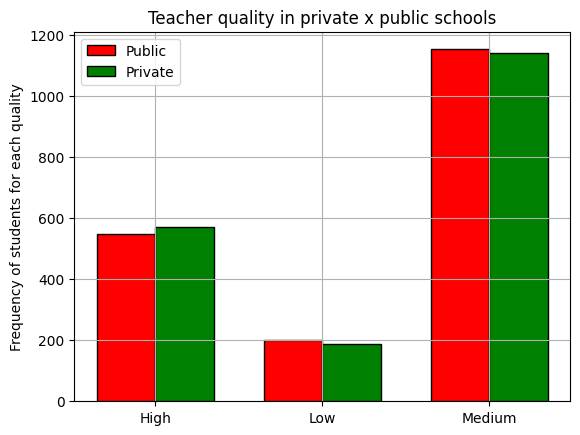

In [101]:


teacher_qlt_public = pd.read_sql("SELECT School_Type, count(*) as num, Teacher_Quality" \
                          " FROM (SELECT * FROM students WHERE School_Type = 'Public'" \
                          " LIMIT 1900)" \
                          " GROUP BY Teacher_Quality", engine)

teacher_qlt = pd.read_sql("SELECT School_Type, count(*) as num, Teacher_Quality" \
                          " FROM (SELECT * FROM students WHERE School_Type = 'Private'" \
                          " LIMIT 1900)" \
                          " GROUP BY Teacher_Quality", engine)

labels = teacher_qlt['Teacher_Quality']
x = np.arange(len(labels))  # [0,1,2,...] para cada categoria

width = 0.35  # largura de cada barra

plt.bar(x - width/2, teacher_qlt_public['num'], width, color="red", label="Public", edgecolor="black")
plt.bar(x + width/2, teacher_qlt['num'], width, color="green", label="Private", edgecolor="black")
plt.xticks(x, labels)  # coloca os rótulos originais
plt.legend()
plt.title("Teacher quality in private x public schools")
plt.ylabel("Frequency of students for each quality")
plt.grid(True)



In [103]:
concat = []
concat.append(teacher_qlt)
concat.append(teacher_qlt_public)
final = pd.concat(concat, ignore_index=True)

final.head(10)

,School_Type,num,Teacher_Quality
0,Private,572,High
1,Private,187,Low
2,Private,1141,Medium
3,Public,548,High
4,Public,200,Low
5,Public,1152,Medium


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6607 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje